# Semantic segmentation of aerial imagery - UNet in PyTorch

Notebook realizuje zadania:

1. pobranie datasetu Kaggle `humansintheloop/semantic-segmentation-of-aerial-imagery`,
2. pierwszą analizę danych i balansu klas,
3. zbudowanie i trenowanie modelu UNet w PyTorch z `nn.CrossEntropyLoss`,
4. wizualizację filtrów konwolucyjnych,
5. ewaluację jakości oraz porównanie wyników między klasami.

Uwaga praktyczna: maski PNG w tej wersji datasetu używają rzeczywistej palety RGB innej niż kolory zapisane w `classes.json`, dlatego dekoder poniżej opiera się na kolorach odczytanych bezpośrednio z masek.


## 1. Pobranie danych


In [1]:
from pathlib import Path
import shutil

DATASET_SLUG = "humansintheloop/semantic-segmentation-of-aerial-imagery"
DATA_DIR = Path("data/semantic-segmentation-of-aerial-imagery")

def download_dataset(data_dir: Path = DATA_DIR) -> Path:
    """Download the Kaggle dataset with kagglehub and keep a local project copy."""
    try:
        import kagglehub
    except ImportError:
        import sys, subprocess
        subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", "kagglehub"])
        import kagglehub

    data_dir.parent.mkdir(parents=True, exist_ok=True)
    if not data_dir.exists() or not any(data_dir.rglob("*.jpg")):
        cache_path = Path(kagglehub.dataset_download(DATASET_SLUG))
        if data_dir.exists():
            shutil.rmtree(data_dir)
        shutil.copytree(cache_path, data_dir)
    return data_dir

DATA_DIR = download_dataset()
DATASET_ROOT = DATA_DIR / "Semantic segmentation dataset"
print(f"Dataset directory: {DATASET_ROOT.resolve()}")
print(f"Images: {len(list(DATASET_ROOT.glob('Tile */images/*.jpg')))}")
print(f"Masks:  {len(list(DATASET_ROOT.glob('Tile */masks/*.png')))}")


Dataset directory: /Users/piotrpijanowski/Documents/Studia/Semestr 6/advanced_data_mining/pracownia/assignment_9/data/semantic-segmentation-of-aerial-imagery/Semantic segmentation dataset
Images: 72
Masks:  72


## 2. Pierwszy ogląd danych i balans klas


In [2]:
import json
from collections import Counter
import random

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from PIL import Image

SEED = 42
random.seed(SEED)
np.random.seed(SEED)

classes_json = json.loads((DATASET_ROOT / "classes.json").read_text())
print(json.dumps(classes_json, indent=2))


{
  "classes": [
    {
      "title": "Water",
      "shape": "polygon",
      "color": "#50E3C2",
      "geometry_config": {}
    },
    {
      "title": "Land (unpaved area)",
      "shape": "polygon",
      "color": "#F5A623",
      "geometry_config": {}
    },
    {
      "title": "Road",
      "shape": "polygon",
      "color": "#DE597F",
      "geometry_config": {}
    },
    {
      "title": "Building",
      "shape": "polygon",
      "color": "#D0021B",
      "geometry_config": {}
    },
    {
      "title": "Vegetation",
      "shape": "polygon",
      "color": "#417505",
      "geometry_config": {}
    },
    {
      "title": "Unlabeled",
      "shape": "polygon",
      "color": "#9B9B9B",
      "geometry_config": {}
    }
  ],
  "tags": []
}


In [3]:
# Actual RGB palette observed in the mask PNG files.
# Unknown colours, including occasional black pixels, are mapped to Unlabeled.
CLASS_NAMES = ["Water", "Land", "Road", "Building", "Vegetation", "Unlabeled"]
PALETTE = np.array([
    [226, 169,  41],  # Water
    [132,  41, 246],  # Land / unpaved area
    [110, 193, 228],  # Road
    [ 60,  16, 152],  # Building
    [254, 221,  58],  # Vegetation
    [155, 155, 155],  # Unlabeled
], dtype=np.uint8)
IGNORE_INDEX = CLASS_NAMES.index("Unlabeled")

pairs = []
for image_path in sorted(DATASET_ROOT.glob("Tile */images/*.jpg")):
    tile = image_path.parent.parent.name
    mask_path = image_path.parent.parent / "masks" / f"{image_path.stem}.png"
    if mask_path.exists():
        pairs.append({"image": image_path, "mask": mask_path, "tile": tile})

print(f"Paired samples: {len(pairs)}")
print(pd.DataFrame(pairs).groupby("tile").size())

def mask_to_indices(mask_img: Image.Image) -> np.ndarray:
    rgb = np.asarray(mask_img.convert("RGB"), dtype=np.uint8)
    label = np.full(rgb.shape[:2], IGNORE_INDEX, dtype=np.int64)
    for idx, color in enumerate(PALETTE):
        label[np.all(rgb == color, axis=-1)] = idx
    return label

def indices_to_rgb(mask: np.ndarray) -> np.ndarray:
    mask = np.asarray(mask)
    safe_mask = np.clip(mask, 0, len(PALETTE) - 1)
    return PALETTE[safe_mask]

sample_image = Image.open(pairs[0]["image"])
sample_mask = Image.open(pairs[0]["mask"])
print("Example image:", sample_image.size, sample_image.mode)
print("Example mask:", sample_mask.size, sample_mask.mode)


Paired samples: 72
tile
Tile 1    9
Tile 2    9
Tile 3    9
Tile 4    9
Tile 5    9
Tile 6    9
Tile 7    9
Tile 8    9
dtype: int64
Example image: (797, 644) RGB
Example mask: (797, 644) RGB


In [4]:
def fast_color_counts(mask_path: Path) -> Counter:
    rgb = np.asarray(Image.open(mask_path).convert("RGB"), dtype=np.uint32)
    encoded = rgb[..., 0] * 256 * 256 + rgb[..., 1] * 256 + rgb[..., 2]
    values, counts = np.unique(encoded.reshape(-1), return_counts=True)

    palette_codes = {
        int(c[0]) * 256 * 256 + int(c[1]) * 256 + int(c[2]): CLASS_NAMES[i]
        for i, c in enumerate(PALETTE)
    }
    out = Counter()
    for value, count in zip(values, counts):
        out[palette_codes.get(int(value), "Unlabeled")] += int(count)
    return out

pixel_counts = Counter()
per_image_counts = []
for row in pairs:
    counts = fast_color_counts(row["mask"])
    pixel_counts.update(counts)
    per_image_counts.append({**row, **counts})

balance = pd.DataFrame({
    "class": CLASS_NAMES,
    "pixels": [pixel_counts[name] for name in CLASS_NAMES],
})
balance["percent"] = 100 * balance["pixels"] / balance["pixels"].sum()
balance


,class,pixels,percent
0,Water,13482196,13.613946
1,Land,51850363,52.357052
2,Road,9261912,9.352421
3,Building,13177546,13.306319
4,Vegetation,10206379,10.306117
5,Unlabeled,1053847,1.064145


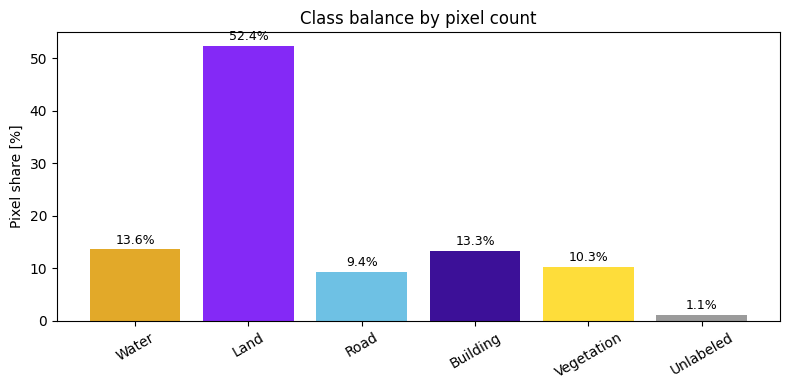

Conclusion: classes are not balanced. Land dominates, while Unlabeled is tiny and is ignored in training/evaluation.


In [5]:
fig, ax = plt.subplots(figsize=(8, 4))
colors = PALETTE / 255
ax.bar(balance["class"], balance["percent"], color=colors)
ax.set_ylabel("Pixel share [%]")
ax.set_title("Class balance by pixel count")
ax.tick_params(axis="x", rotation=30)
for i, value in enumerate(balance["percent"]):
    ax.text(i, value + 0.5, f"{value:.1f}%", ha="center", va="bottom", fontsize=9)
plt.tight_layout()
plt.show()

print("Conclusion: classes are not balanced. Land dominates, while Unlabeled is tiny and is ignored in training/evaluation.")


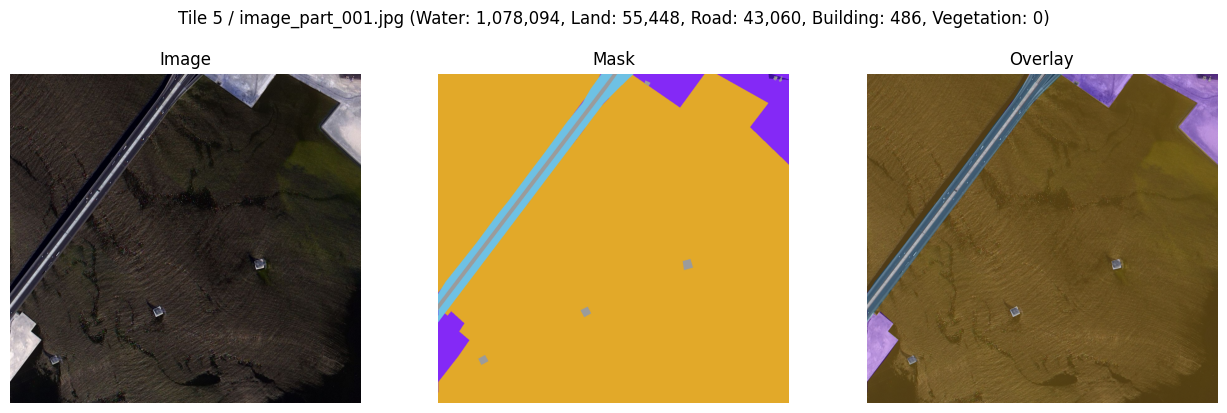

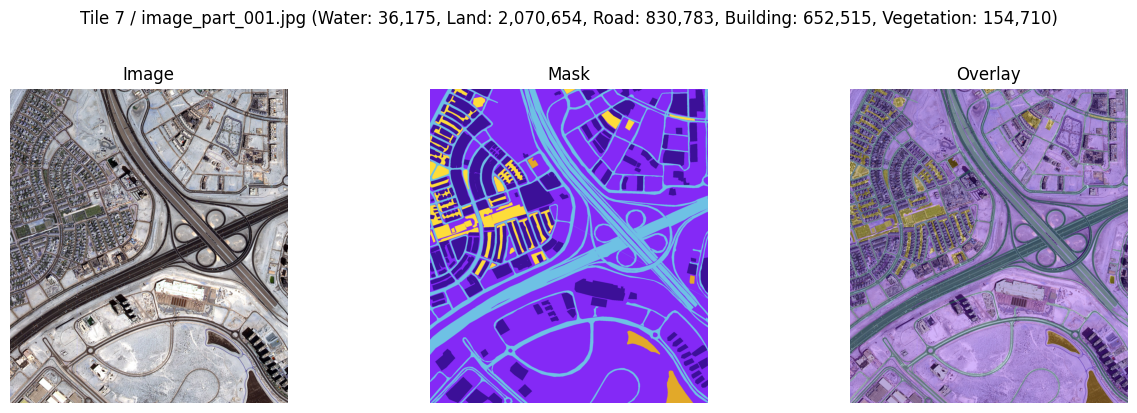

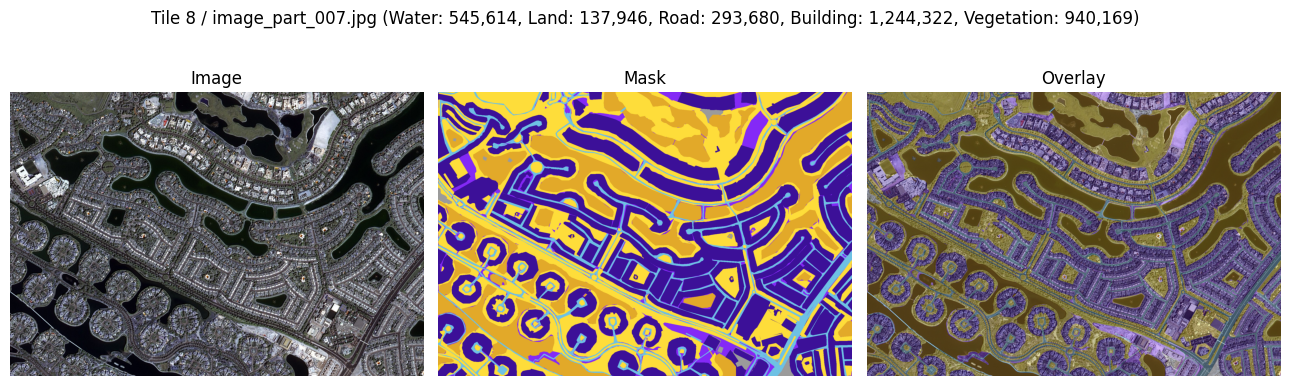

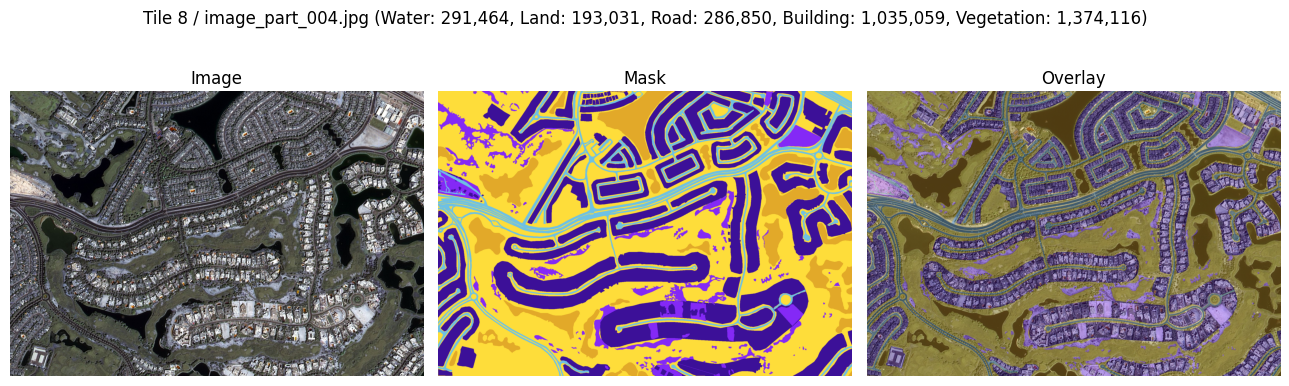

In [6]:
def show_example(row, title=None):
    image = np.asarray(Image.open(row["image"]).convert("RGB"))
    mask_idx = mask_to_indices(Image.open(row["mask"]))
    mask_rgb = indices_to_rgb(mask_idx)
    overlay = (0.65 * image + 0.35 * mask_rgb).astype(np.uint8)

    fig, axes = plt.subplots(1, 3, figsize=(13, 4))
    axes[0].imshow(image)
    axes[0].set_title("Image")
    axes[1].imshow(mask_rgb)
    axes[1].set_title("Mask")
    axes[2].imshow(overlay)
    axes[2].set_title("Overlay")
    for ax in axes:
        ax.axis("off")
    if title:
        fig.suptitle(title, y=1.02)
    plt.tight_layout()
    plt.show()

per_image_df = pd.DataFrame(per_image_counts).fillna(0)
interesting = []
for class_name in ["Water", "Road", "Building", "Vegetation"]:
    interesting.append(per_image_df.sort_values(class_name, ascending=False).iloc[0])

for row in interesting:
    dominant_note = ", ".join(
        f"{name}: {int(row.get(name, 0)):,}" for name in CLASS_NAMES[:-1]
    )
    show_example(row, title=f"{row['tile']} / {row['image'].name} ({dominant_note})")


Wniosek z EDA: klasy nie są zbalansowane. W pobranej kopii danych `Land` stanowi około połowę pikseli, natomiast `Road`, `Building` i `Vegetation` mają znacznie mniejszy udział, a `Unlabeled` jest marginalne. To oznacza, że sama dokładność pikselowa może być myląca, więc w ewaluacji używam również IoU i Dice dla każdej klasy.


## 3. Dataset, model UNet i trening


In [7]:
import torch
from torch import nn
from torch.utils.data import Dataset, DataLoader
import torch.nn.functional as F

try:
    from tqdm.auto import tqdm
except Exception:
    tqdm = lambda x, **kwargs: x

import torchvision.transforms.functional as TF

torch.manual_seed(SEED)

IMAGE_SIZE = (256, 256)
BATCH_SIZE = 4
EPOCHS = 8
LEARNING_RATE = 1e-3

device = torch.device(
    "mps" if torch.backends.mps.is_available()
    else "cuda" if torch.cuda.is_available()
    else "cpu"
)
print("Device:", device)


Device: mps


In [8]:
# Split by tile to reduce leakage between neighbouring image patches.
train_pairs = [p for p in pairs if p["tile"] not in {"Tile 7", "Tile 8"}]
val_pairs = [p for p in pairs if p["tile"] == "Tile 7"]
test_pairs = [p for p in pairs if p["tile"] == "Tile 8"]

print(f"Train: {len(train_pairs)} | Val: {len(val_pairs)} | Test: {len(test_pairs)}")

class AerialSegmentationDataset(Dataset):
    def __init__(self, rows, image_size=IMAGE_SIZE, augment=False):
        self.rows = list(rows)
        self.image_size = image_size
        self.augment = augment
        self.mean = np.array([0.485, 0.456, 0.406], dtype=np.float32)
        self.std = np.array([0.229, 0.224, 0.225], dtype=np.float32)

    def __len__(self):
        return len(self.rows)

    def __getitem__(self, idx):
        row = self.rows[idx]
        image = Image.open(row["image"]).convert("RGB").resize(self.image_size, Image.Resampling.BILINEAR)
        mask_image = Image.open(row["mask"]).convert("RGB").resize(self.image_size, Image.Resampling.NEAREST)
        mask = mask_to_indices(mask_image)

        if self.augment and random.random() < 0.5:
            image = image.transpose(Image.Transpose.FLIP_LEFT_RIGHT)
            mask = np.fliplr(mask).copy()

        image = np.asarray(image, dtype=np.float32) / 255.0
        image = (image - self.mean) / self.std
        image = torch.from_numpy(image.transpose(2, 0, 1)).float()
        mask = torch.from_numpy(mask).long()
        return image, mask

train_ds = AerialSegmentationDataset(train_pairs, augment=True)
val_ds = AerialSegmentationDataset(val_pairs)
test_ds = AerialSegmentationDataset(test_pairs)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, num_workers=0)
val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)
test_loader = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)


Train: 54 | Val: 9 | Test: 9


In [ ]:
class DoubleConv(nn.Module):
    def __init__(self, in_channels, out_channels):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(in_channels, out_channels, kernel_size=3, padding=1),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_channels, out_channels, kernel_size=3, padding=1),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),
        )

    def forward(self, x):
        return self.net(x)

class UNet(nn.Module):
    def __init__(self, num_classes, base_channels=16):
        super().__init__()
        self.enc1 = DoubleConv(3, base_channels)
        self.enc2 = DoubleConv(base_channels, base_channels * 2)
        self.enc3 = DoubleConv(base_channels * 2, base_channels * 4)
        self.pool = nn.MaxPool2d(2)

        self.bottleneck = DoubleConv(base_channels * 4, base_channels * 8)

        self.up3 = nn.ConvTranspose2d(base_channels * 8, base_channels * 4, kernel_size=2, stride=2)
        self.dec3 = DoubleConv(base_channels * 8, base_channels * 4)
        self.up2 = nn.ConvTranspose2d(base_channels * 4, base_channels * 2, kernel_size=2, stride=2)
        self.dec2 = DoubleConv(base_channels * 4, base_channels * 2)
        self.up1 = nn.ConvTranspose2d(base_channels * 2, base_channels, kernel_size=2, stride=2)
        self.dec1 = DoubleConv(base_channels * 2, base_channels)

        self.out_conv = nn.Conv2d(base_channels, num_classes, kernel_size=1)

    def forward(self, x):
        e1 = self.enc1(x)
        e2 = self.enc2(self.pool(e1))
        e3 = self.enc3(self.pool(e2))
        b = self.bottleneck(self.pool(e3))

        d3 = self.up3(b)
        d3 = self.dec3(torch.cat([d3, e3], dim=1))
        d2 = self.up2(d3)
        d2 = self.dec2(torch.cat([d2, e2], dim=1))
        d1 = self.up1(d2)
        d1 = self.dec1(torch.cat([d1, e1], dim=1))
        return self.out_conv(d1)

model = UNet(num_classes=len(CLASS_NAMES), base_channels=16).to(device)
print(model)


UNet(
  (enc1): DoubleConv(
    (net): Sequential(
      (0): Conv2d(3, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (1): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): ReLU(inplace=True)
      (3): Conv2d(16, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (4): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (5): ReLU(inplace=True)
    )
  )
  (enc2): DoubleConv(
    (net): Sequential(
      (0): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): ReLU(inplace=True)
      (3): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (4): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (5): ReLU(inplace=True)
    )
  )
  (enc3): DoubleConv(
    (net): Sequential(
      (0): Conv2d(32, 64, kernel_size=(3, 3), st

In [10]:
def class_counts_for_dataset(dataset):
    counts = torch.zeros(len(CLASS_NAMES), dtype=torch.float64)
    loader = DataLoader(dataset, batch_size=1, shuffle=False, num_workers=0)
    for _, mask in loader:
        counts += torch.bincount(mask.flatten(), minlength=len(CLASS_NAMES))
    return counts

train_counts = class_counts_for_dataset(AerialSegmentationDataset(train_pairs, augment=False))
train_freq = train_counts / train_counts[:IGNORE_INDEX].sum()

# Weighted CrossEntropyLoss is still Cross Entropy, but helps minority classes.
class_weights = torch.ones(len(CLASS_NAMES), dtype=torch.float32)
class_weights[:IGNORE_INDEX] = 1.0 / torch.log(1.02 + train_freq[:IGNORE_INDEX].float())
class_weights[IGNORE_INDEX] = 0.0

criterion = nn.CrossEntropyLoss(weight=class_weights.to(device), ignore_index=IGNORE_INDEX)
optimizer = torch.optim.AdamW(model.parameters(), lr=LEARNING_RATE, weight_decay=1e-4)

pd.DataFrame({
    "class": CLASS_NAMES,
    "train_pixels": train_counts.numpy().astype(int),
    "loss_weight": class_weights.numpy(),
})


,class,train_pixels,loss_weight
0,Water,949192,3.914182
1,Land,1534254,2.651227
2,Road,301564,9.914478
3,Building,380626,8.259668
4,Vegetation,335848,9.117806
5,Unlabeled,37460,0.000000


In [11]:
def fast_confusion_matrix(pred, target, num_classes=len(CLASS_NAMES), ignore_index=IGNORE_INDEX):
    mask = target != ignore_index
    combined = target[mask] * num_classes + pred[mask]
    return torch.bincount(combined.flatten(), minlength=num_classes ** 2).reshape(num_classes, num_classes).cpu()

def metrics_from_confusion(hist):
    hist = hist.float()
    true_positive = torch.diag(hist)
    support = hist.sum(dim=1)
    predicted = hist.sum(dim=0)
    denominator_iou = support + predicted - true_positive
    denominator_dice = support + predicted

    iou = true_positive / denominator_iou.clamp_min(1)
    dice = 2 * true_positive / denominator_dice.clamp_min(1)
    pixel_acc = true_positive.sum() / hist.sum().clamp_min(1)
    mean_iou = iou[:IGNORE_INDEX].mean()
    mean_dice = dice[:IGNORE_INDEX].mean()
    return {
        "pixel_acc": float(pixel_acc),
        "mean_iou": float(mean_iou),
        "mean_dice": float(mean_dice),
        "iou": iou.numpy(),
        "dice": dice.numpy(),
    }

def run_epoch(loader, train=False):
    model.train(train)
    total_loss = 0.0
    hist = torch.zeros((len(CLASS_NAMES), len(CLASS_NAMES)), dtype=torch.int64)

    for images, masks in tqdm(loader, leave=False):
        images = images.to(device)
        masks = masks.to(device)

        with torch.set_grad_enabled(train):
            logits = model(images)
            loss = criterion(logits, masks)
            if train:
                optimizer.zero_grad()
                loss.backward()
                optimizer.step()

        total_loss += loss.item() * images.size(0)
        preds = logits.argmax(dim=1)
        hist += fast_confusion_matrix(preds.cpu(), masks.cpu())

    metrics = metrics_from_confusion(hist)
    metrics["loss"] = total_loss / len(loader.dataset)
    metrics["hist"] = hist
    return metrics


In [12]:
history = []
best_val_iou = -1
best_state = None

for epoch in range(1, EPOCHS + 1):
    train_metrics = run_epoch(train_loader, train=True)
    val_metrics = run_epoch(val_loader, train=False)

    row = {
        "epoch": epoch,
        "train_loss": train_metrics["loss"],
        "train_mIoU": train_metrics["mean_iou"],
        "val_loss": val_metrics["loss"],
        "val_mIoU": val_metrics["mean_iou"],
        "val_pixel_acc": val_metrics["pixel_acc"],
    }
    history.append(row)
    print(
        f"Epoch {epoch:02d}/{EPOCHS} | "
        f"train loss {row['train_loss']:.4f}, mIoU {row['train_mIoU']:.3f} | "
        f"val loss {row['val_loss']:.4f}, mIoU {row['val_mIoU']:.3f}, acc {row['val_pixel_acc']:.3f}"
    )

    if val_metrics["mean_iou"] > best_val_iou:
        best_val_iou = val_metrics["mean_iou"]
        best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}

if best_state is not None:
    model.load_state_dict(best_state)

Path("outputs").mkdir(exist_ok=True)
torch.save(model.state_dict(), "outputs/unet_aerial_segmentation.pt")
pd.DataFrame(history)


  0%|          | 0/14 [00:00<?, ?it/s]

  0%|          | 0/3 [00:00<?, ?it/s]

Epoch 01/8 | train loss 1.5504, mIoU 0.272 | val loss 1.6106, mIoU 0.179, acc 0.707


  0%|          | 0/14 [00:00<?, ?it/s]

  0%|          | 0/3 [00:00<?, ?it/s]

...

Epoch 07/8 | train loss 1.0595, mIoU 0.500 | val loss 1.0613, mIoU 0.456, acc 0.756


  0%|          | 0/14 [00:00<?, ?it/s]

  0%|          | 0/3 [00:00<?, ?it/s]

Epoch 08/8 | train loss 1.0402, mIoU 0.499 | val loss 1.2084, mIoU 0.360, acc 0.685


,epoch,train_loss,train_mIoU,val_loss,val_mIoU,val_pixel_acc
0,1,1.550409,0.271807,1.610554,0.179240,0.706990
1,2,1.345226,0.380914,1.330932,0.303046,0.752720
2,3,1.272859,0.412223,1.241131,0.365546,0.730457
3,4,1.301295,0.409291,1.239333,0.300896,0.709323
4,5,1.235368,0.406563,1.142849,0.352343,0.720380
5,6,1.121169,0.482888,1.208540,0.370916,0.645829
6,7,1.059458,0.500014,1.061334,0.456122,0.755862
7,8,1.040200,0.498707,1.208372,0.359791,0.684835


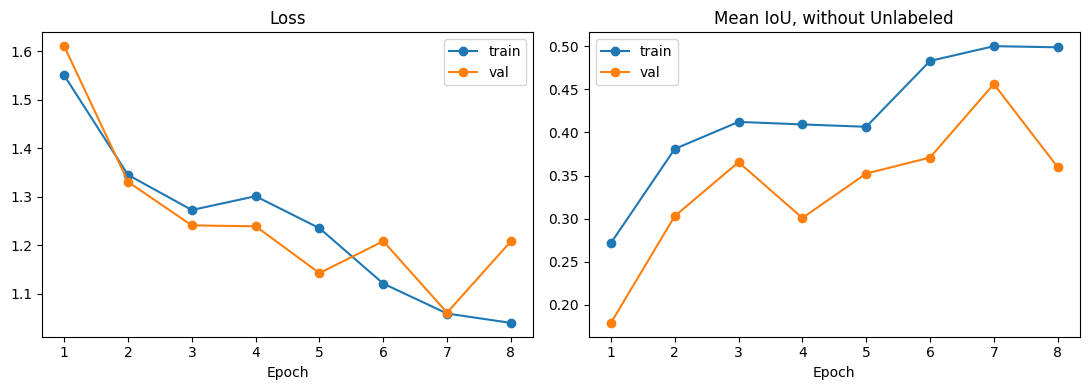

In [13]:
history_df = pd.DataFrame(history)
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].plot(history_df["epoch"], history_df["train_loss"], marker="o", label="train")
axes[0].plot(history_df["epoch"], history_df["val_loss"], marker="o", label="val")
axes[0].set_title("Loss")
axes[0].set_xlabel("Epoch")
axes[0].legend()

axes[1].plot(history_df["epoch"], history_df["train_mIoU"], marker="o", label="train")
axes[1].plot(history_df["epoch"], history_df["val_mIoU"], marker="o", label="val")
axes[1].set_title("Mean IoU, without Unlabeled")
axes[1].set_xlabel("Epoch")
axes[1].legend()
plt.tight_layout()
plt.show()


## 4. Wizualizacja filtrów konwolucyjnych


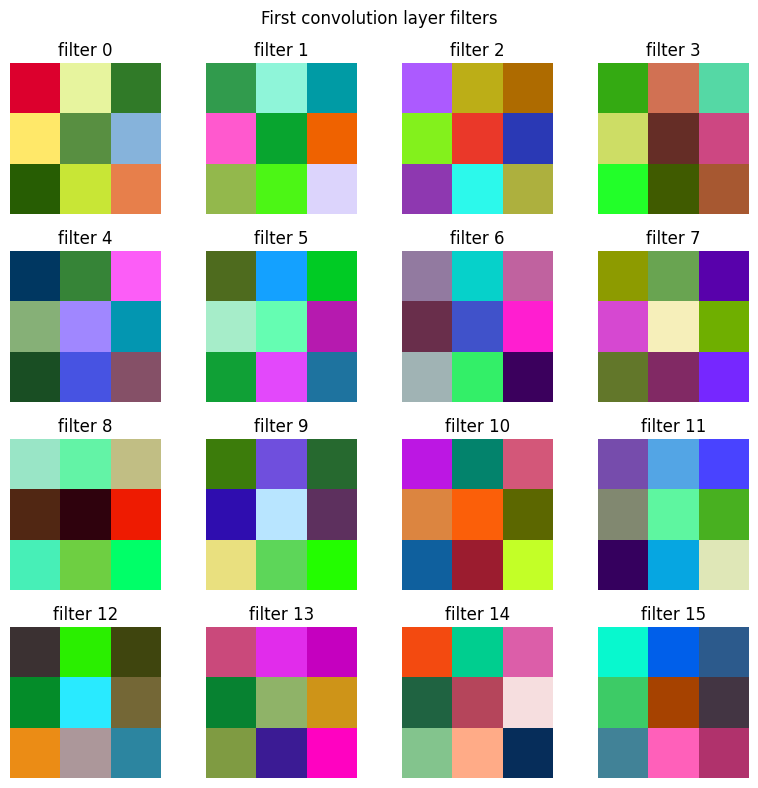

In [14]:
def plot_first_layer_filters(model, max_filters=16):
    weights = model.enc1.net[0].weight.detach().cpu().numpy()
    n = min(max_filters, weights.shape[0])
    cols = 4
    rows = int(np.ceil(n / cols))
    fig, axes = plt.subplots(rows, cols, figsize=(8, 2 * rows))
    axes = np.array(axes).reshape(-1)
    for i in range(n):
        filt = weights[i].transpose(1, 2, 0)
        filt = (filt - filt.min()) / (filt.max() - filt.min() + 1e-8)
        axes[i].imshow(filt)
        axes[i].set_title(f"filter {i}")
        axes[i].axis("off")
    for ax in axes[n:]:
        ax.axis("off")
    fig.suptitle("First convolution layer filters")
    plt.tight_layout()
    plt.show()

plot_first_layer_filters(model)


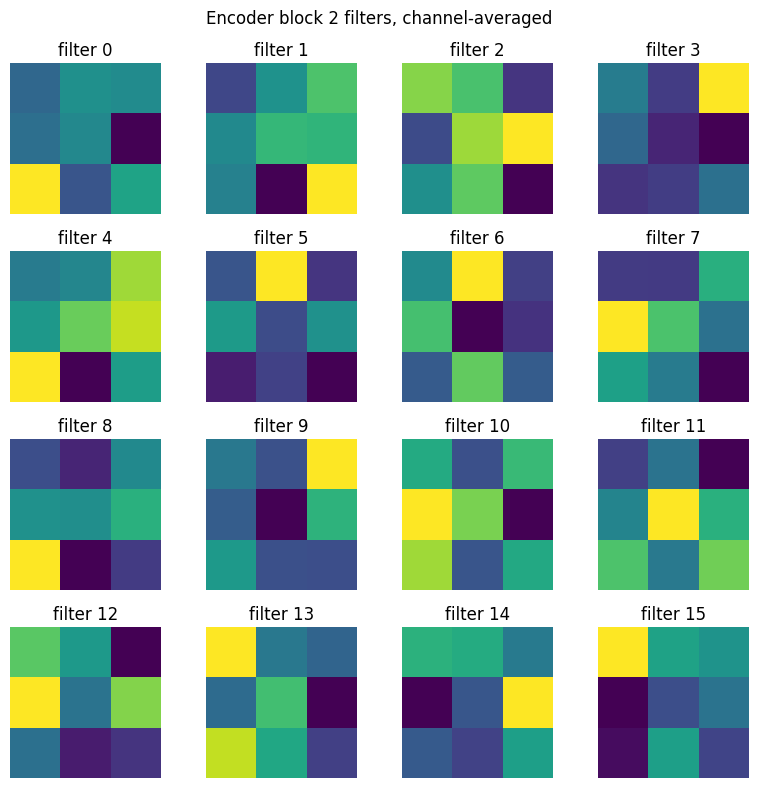

In [15]:
def plot_deeper_conv_filters(conv_layer, max_filters=16, title="Deeper convolution filters"):
    weights = conv_layer.weight.detach().cpu().numpy()
    # Deeper filters have many input channels, so average absolute activation weights across input channels.
    maps = np.mean(np.abs(weights), axis=1)
    n = min(max_filters, maps.shape[0])
    cols = 4
    rows = int(np.ceil(n / cols))
    fig, axes = plt.subplots(rows, cols, figsize=(8, 2 * rows))
    axes = np.array(axes).reshape(-1)
    for i in range(n):
        filt = maps[i]
        filt = (filt - filt.min()) / (filt.max() - filt.min() + 1e-8)
        axes[i].imshow(filt, cmap="viridis")
        axes[i].set_title(f"filter {i}")
        axes[i].axis("off")
    for ax in axes[n:]:
        ax.axis("off")
    fig.suptitle(title)
    plt.tight_layout()
    plt.show()

plot_deeper_conv_filters(model.enc2.net[0], title="Encoder block 2 filters, channel-averaged")


Interpretacja filtrów: w pierwszej warstwie zwykle widać proste detektory kontrastu, koloru i krawędzi, co jest użyteczne dla dróg, granic budynków oraz przejść między wodą i lądem. Filtry głębszych warstw są mniej czytelne wizualnie, bo działają na mapach cech, a nie bezpośrednio na RGB; po krótkim treningu część z nich wygląda jeszcze dość losowo.


## 5. Ewaluacja wyników


### Czym są IoU i Dice?

W segmentacji semantycznej model przypisuje klasę do każdego piksela. Dlatego dla każdej klasy osobno możemy porównać maskę przewidzianą przez model z maską prawdziwą.

Dla jednej klasy liczymy:

- **TP** (*true positives*) - piksele, które naprawdę należą do tej klasy i model też przypisał je do tej klasy,
- **FP** (*false positives*) - piksele, które model błędnie przypisał do tej klasy,
- **FN** (*false negatives*) - piksele tej klasy, których model nie znalazł.

**IoU** (*Intersection over Union*, Jaccard index) mierzy część wspólną predykcji i prawdziwej maski względem ich sumy:

\[
IoU = \frac{TP}{TP + FP + FN}
\]

Wartość `1.0` oznacza idealne pokrycie maski, a `0.0` oznacza brak trafnego pokrycia. IoU jest dość surową metryką, bo karze zarówno nadmiarowe piksele (`FP`), jak i brakujące piksele (`FN`).

**Dice** mierzy podobieństwo dwóch masek, ale trochę mocniej nagradza część wspólną:

\[
Dice = \frac{2TP}{2TP + FP + FN}
\]

Dice także ma zakres od `0.0` do `1.0`. Dla tych samych predykcji Dice jest zwykle liczbowo wyższy niż IoU, ale ranking klas często pozostaje podobny.

W tym notebooku `mean IoU` i `mean Dice` oznaczają średnią po klasach, z pominięciem `Unlabeled`. To jest ważniejsze niż sama dokładność pikselowa, bo dataset jest niezbalansowany: model może mieć wysoką accuracy dzięki dominującej klasie, a jednocześnie słabo przewidywać rzadsze klasy, np. `Road`.

In [16]:
test_metrics = run_epoch(test_loader, train=False)
per_class = pd.DataFrame({
    "class": CLASS_NAMES,
    "IoU": test_metrics["iou"],
    "Dice": test_metrics["dice"],
})
print(f"Test pixel accuracy: {test_metrics['pixel_acc']:.3f}")
print(f"Test mean IoU without Unlabeled: {test_metrics['mean_iou']:.3f}")
print(f"Test mean Dice without Unlabeled: {test_metrics['mean_dice']:.3f}")
per_class


  0%|          | 0/3 [00:00<?, ?it/s]

Test pixel accuracy: 0.671
Test mean IoU without Unlabeled: 0.473
Test mean Dice without Unlabeled: 0.622


,class,IoU,Dice
0,Water,0.634375,0.776290
1,Land,0.725703,0.841052
2,Road,0.254291,0.405474
3,Building,0.431143,0.602515
4,Vegetation,0.321714,0.486813
5,Unlabeled,0.000000,0.000000


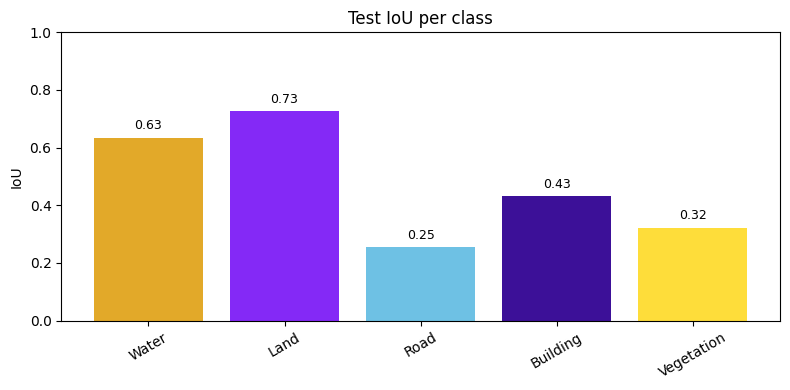

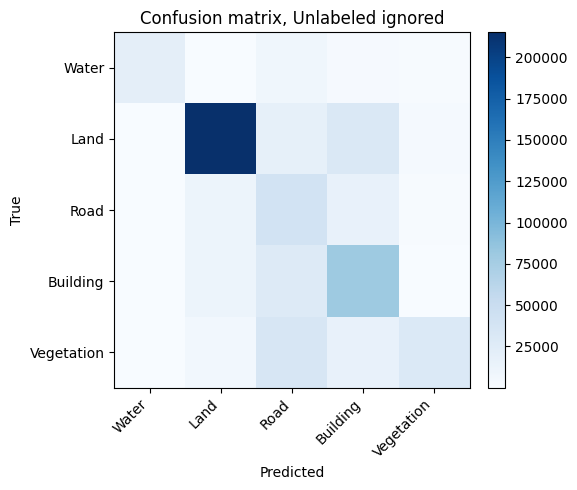

In [17]:
fig, ax = plt.subplots(figsize=(8, 4))
plot_df = per_class.iloc[:IGNORE_INDEX]
ax.bar(plot_df["class"], plot_df["IoU"], color=PALETTE[:IGNORE_INDEX] / 255)
ax.set_ylim(0, 1)
ax.set_ylabel("IoU")
ax.set_title("Test IoU per class")
ax.tick_params(axis="x", rotation=30)
for i, value in enumerate(plot_df["IoU"]):
    ax.text(i, value + 0.02, f"{value:.2f}", ha="center", va="bottom", fontsize=9)
plt.tight_layout()
plt.show()

hist = test_metrics["hist"].numpy()
fig, ax = plt.subplots(figsize=(6, 5))
im = ax.imshow(hist[:IGNORE_INDEX, :IGNORE_INDEX], cmap="Blues")
ax.set_xticks(range(IGNORE_INDEX), CLASS_NAMES[:IGNORE_INDEX], rotation=45, ha="right")
ax.set_yticks(range(IGNORE_INDEX), CLASS_NAMES[:IGNORE_INDEX])
ax.set_xlabel("Predicted")
ax.set_ylabel("True")
ax.set_title("Confusion matrix, Unlabeled ignored")
fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
plt.tight_layout()
plt.show()


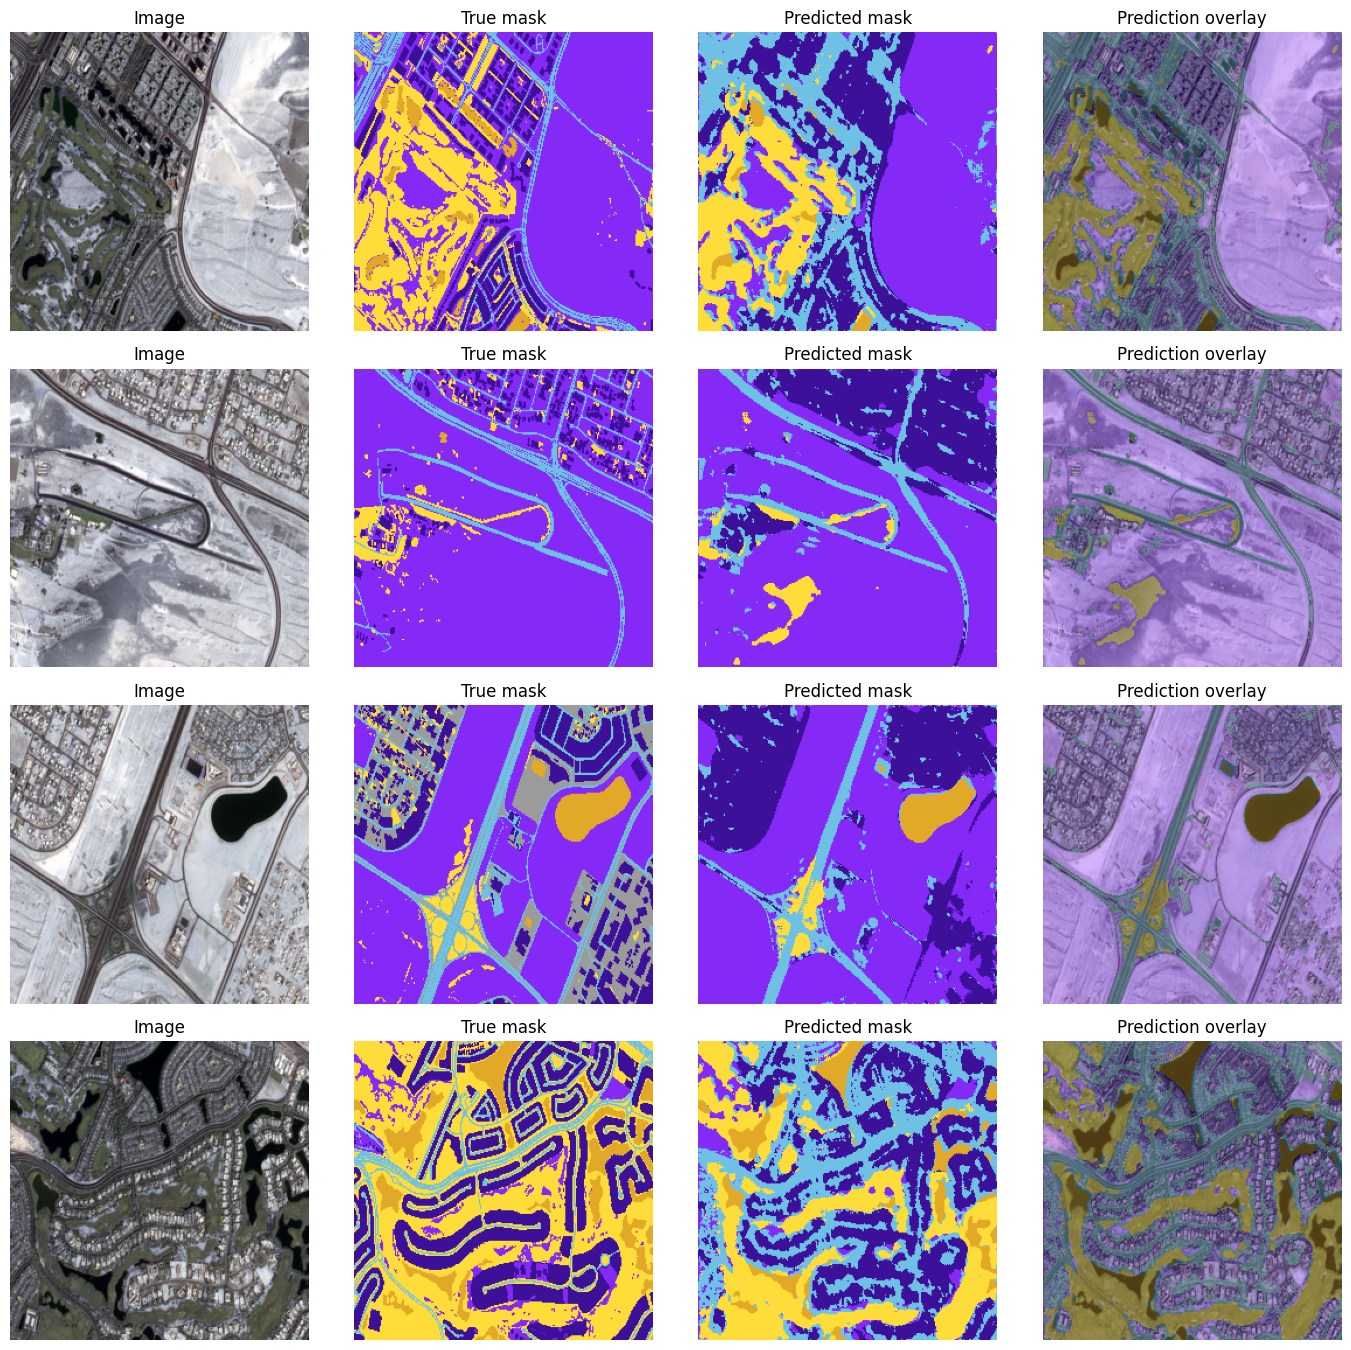

In [18]:
def denormalize(image_tensor):
    mean = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
    std = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)
    image = image_tensor.cpu() * std + mean
    return image.clamp(0, 1).permute(1, 2, 0).numpy()

@torch.no_grad()
def show_predictions(dataset, n=4):
    model.eval()
    indices = list(range(min(n, len(dataset))))
    fig, axes = plt.subplots(len(indices), 4, figsize=(14, 3.4 * len(indices)))
    if len(indices) == 1:
        axes = axes[None, :]

    for row_idx, idx in enumerate(indices):
        image, mask = dataset[idx]
        logits = model(image.unsqueeze(0).to(device))
        pred = logits.argmax(dim=1).squeeze(0).cpu().numpy()

        axes[row_idx, 0].imshow(denormalize(image))
        axes[row_idx, 0].set_title("Image")
        axes[row_idx, 1].imshow(indices_to_rgb(mask.numpy()))
        axes[row_idx, 1].set_title("True mask")
        axes[row_idx, 2].imshow(indices_to_rgb(pred))
        axes[row_idx, 2].set_title("Predicted mask")
        overlay = (0.65 * denormalize(image) * 255 + 0.35 * indices_to_rgb(pred)).astype(np.uint8)
        axes[row_idx, 3].imshow(overlay)
        axes[row_idx, 3].set_title("Prediction overlay")

        for ax in axes[row_idx]:
            ax.axis("off")

    plt.tight_layout()
    plt.show()

show_predictions(test_ds, n=4)


In [19]:
valid_results = per_class.iloc[:IGNORE_INDEX].sort_values("IoU", ascending=False)
best = valid_results.iloc[0]
worst = valid_results.iloc[-1]
print(
    f"Najlepsza klasa według IoU: {best['class']} ({best['IoU']:.3f}).\n"
    f"Najtrudniejsza klasa według IoU: {worst['class']} ({worst['IoU']:.3f})."
)
print(
    "Model zwykle lepiej radzi sobie z dużymi, zwartymi obszarami, a gorzej z klasami "
    "rzadszymi albo cienkimi przestrzennie, takimi jak drogi. Wyniki zależą od krótkiego "
    "treningu, rozmiaru wejścia 256x256 i małej liczby obrazów w zbiorze testowym."
)


Najlepsza klasa według IoU: Land (0.726).
Najtrudniejsza klasa według IoU: Road (0.254).
Model zwykle lepiej radzi sobie z dużymi, zwartymi obszarami, a gorzej z klasami rzadszymi albo cienkimi przestrzennie, takimi jak drogi. Wyniki zależą od krótkiego treningu, rozmiaru wejścia 256x256 i małej liczby obrazów w zbiorze testowym.
